In [1]:
%pip install --upgrade shap>=0.51.0


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import learning_curve
import shap

# Configure publication-quality styles for Springer Nature (Single Column Layout)
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 13,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# =====================================================================
# 1. ĐỊNH NGHĨA ĐƯỜNG DẪN RIÊNG BIỆT (TÁCH BIỆT DATA & MODEL)
# =====================================================================

# Thư mục chứa Model và Feature Names (.pkl) nằm cùng cấp với Notebook hiện tại
MODEL_DIR = os.path.abspath('artifacts') 

# Thư mục chứa Dữ liệu (.csv) nằm ở thư mục cha (Parent Directory)
BASE_DIR = os.path.dirname(os.getcwd()) 
DATA_DIR = os.path.join(BASE_DIR, 'artifacts')

print(f"📦 Thư mục chứa Model/Artifacts (.pkl): {MODEL_DIR}")
print(f"📂 Thư mục chứa Dữ liệu (.csv):         {DATA_DIR}")

# =====================================================================
# 2. LOAD MODEL & FEATURES (Từ thư mục MODEL_DIR)
# =====================================================================
model = joblib.load(os.path.join(MODEL_DIR, 'xgb_model_churn.pkl'))
feature_names = joblib.load(os.path.join(MODEL_DIR, 'trained_features.pkl'))

# =====================================================================
# 3. LOAD DATA TRAIN/TEST (Từ thư mục DATA_DIR)
# =====================================================================
X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train_tree.csv'))
X_test = pd.read_csv(os.path.join(DATA_DIR, 'X_test_tree.csv'))
y_train = pd.read_csv(os.path.join(DATA_DIR, 'y_train_tree.csv')).squeeze()
y_test = pd.read_csv(os.path.join(DATA_DIR, 'y_test_tree.csv')).squeeze()

# 4. Dự đoán xác suất phục vụ cho các biểu đồ Threshold/PR-Curve
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("\n✅ [IMPORT SUCCESS] All components reloaded into isolated memory!")
print(f"🔹 Model Type: {type(model).__name__}")
print(f"🔹 Test Data Shape: {X_test.shape}")

📦 Thư mục chứa Model/Artifacts (.pkl): d:\FPTU_Study\SU2026\ADY201m\Project_ADY201m_GR01_AI2009_H1\notebooks\artifacts
📂 Thư mục chứa Dữ liệu (.csv):         d:\FPTU_Study\SU2026\ADY201m\Project_ADY201m_GR01_AI2009_H1\artifacts

✅ [IMPORT SUCCESS] All components reloaded into isolated memory!
🔹 Model Type: XGBClassifier
🔹 Test Data Shape: (1409, 18)


C:\Users\HGB\AppData\Local\Temp\ipykernel_9312\3968962911.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



✅ Đã lưu biểu đồ thành công tại: d:\FPTU_Study\SU2026\ADY201m\Project_ADY201m_GR01_AI2009_H1\notebooks\artifacts\xgboost_feature_importance.png



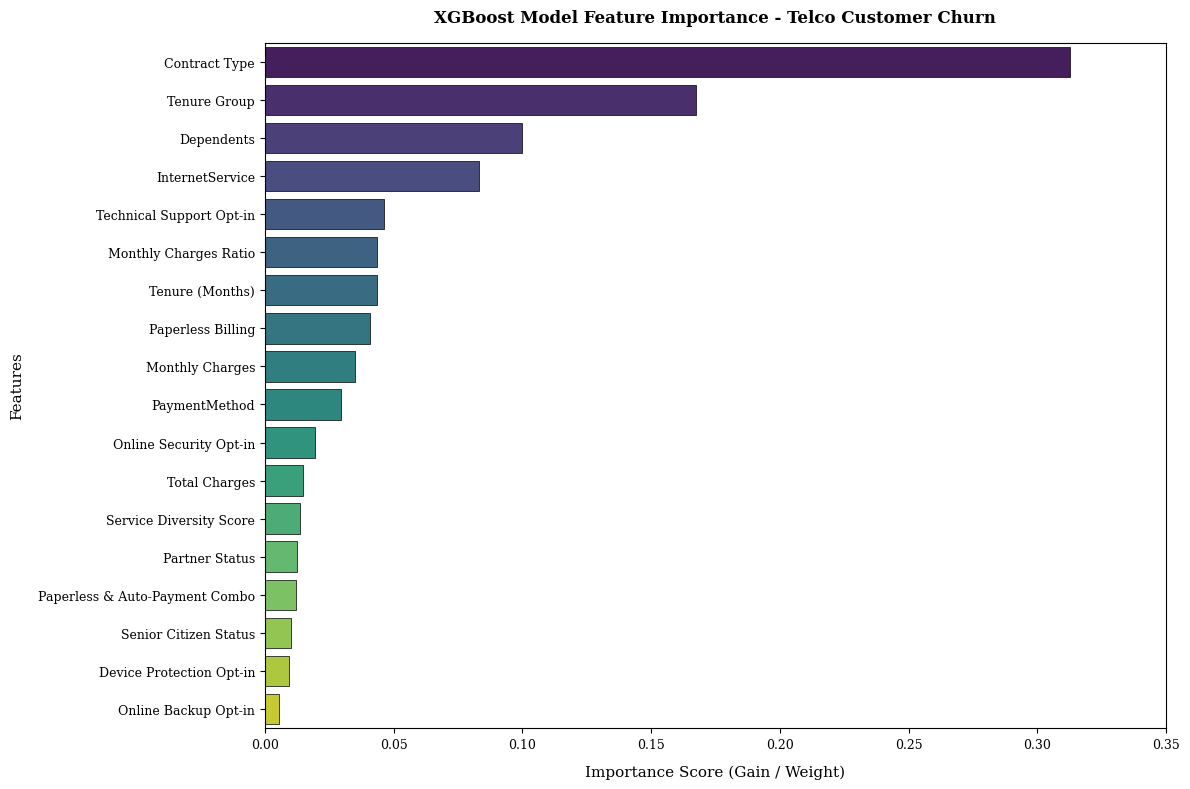

📌 Top 5 Most Influential Features Driving Customer Churn:
-----------------------------------------------------------------
                 Feature  Importance (%)
           Contract Type           31.28
            Tenure Group           16.73
              Dependents           10.00
         InternetService            8.31
Technical Support Opt-in            4.64
-----------------------------------------------------------------


In [3]:
# =====================================================================
# 5. TÍNH TOÁN VÀ TRỰC QUAN HÓA FEATURE IMPORTANCE
# =====================================================================

# 1. Từ điển map tên các đặc trưng cho đẹp mắt (Custom Names)
custom_names = {
    # Nhóm biến sinh ra từ One-Hot Encoding
    'Dependents_Yes': 'Dependents: Yes',
    'PaymentMethod_Credit card (automatic)': 'Payment Method: Credit Card (Auto)',
    'PaymentMethod_Electronic check': 'Payment Method: Electronic Check',
    'PaymentMethod_Mailed check': 'Payment Method: Mailed Check',
    'InternetService_Fiber optic': 'Internet Service: Fiber Optic',
    'InternetService_No': 'Internet Service: None',
    'tenure_group' : 'Tenure Group',
    'tenure_group_13-24 months': 'Tenure Group: 13-24 Months',
    'tenure_group_25-36 months': 'Tenure Group: 25-36 Months',
    'tenure_group_37-48 months': 'Tenure Group: 37-48 Months',
    'tenure_group_49-60 months': 'Tenure Group: 49-60 Months',
    'tenure_group_61-72 months': 'Tenure Group: 61-72 Months',
    
    # Nhóm biến số / Nhị phân giữ nguyên (Remainder)
    'SeniorCitizen': 'Senior Citizen Status',
    'Partner': 'Partner Status',
    'Tenure': 'Tenure (Months)',
    'Contract': 'Contract Type',
    'PaperlessBilling': 'Paperless Billing',
    'MonthlyCharges': 'Monthly Charges',
    'TotalCharges': 'Total Charges',
    'OnlineSecurity': 'Online Security Opt-in',
    'OnlineBackup': 'Online Backup Opt-in',
    'DeviceProtection': 'Device Protection Opt-in',
    'TechSupport': 'Technical Support Opt-in',
    
    # Nhóm Feature Engineering
    'service_diversity': 'Service Diversity Score',
    'monthly_charges_ratio': 'Monthly Charges Ratio',
    'is_paperless_electronic': 'Paperless & Auto-Payment Combo'
}

# 2. Tạo DataFrame tầm quan trọng (Sử dụng 'model' và 'feature_names' đã load từ memory)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

# Dùng Regex làm sạch tên (xóa triệt để tiền tố encoder__, remainder__)
importance_df['Feature'] = (
    importance_df['Feature']
    .str.replace(r'^(encoder__|remainder__)', '', regex=True)
    .str.strip()
)

# 3. Áp dụng Mapping
importance_df['Feature'] = importance_df['Feature'].map(custom_names).fillna(importance_df['Feature'])

# Sắp xếp giá trị Importance giảm dần và thêm cột phần trăm (%)
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df["Importance (%)"] = (importance_df["Importance"] * 100).round(2)


# ==========================================
# 4. VẼ BIỂU ĐỒ FEATURE IMPORTANCE
# ==========================================
plt.figure(figsize=(12, 8))

# Vẽ Barplot ngang
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    palette='viridis',
    edgecolor='black',
    linewidth=0.5
)

# Cấu hình Tiêu đề và Nhãn
plt.title('XGBoost Model Feature Importance - Telco Customer Churn', fontweight='bold', pad=15)
plt.xlabel('Importance Score (Gain / Weight)', labelpad=10)
plt.ylabel('Features', labelpad=10)

# Cấu hình chia vạch trục X linh hoạt theo giá trị max thực tế của model thay vì hardcode 0.40
max_imp = importance_df['Importance'].max()
plt.xticks(np.arange(0, max_imp + 0.05, 0.05))

plt.tight_layout()

# Lưu hình ảnh (Đã chuyển đường dẫn lưu vào chung MODEL_DIR để giữ sự ngăn nắp)
save_path = os.path.join(MODEL_DIR, 'xgboost_feature_importance.png')
plt.savefig(save_path, transparent=False, facecolor='white')
print(f"\n✅ Đã lưu biểu đồ thành công tại: {save_path}\n")

plt.show()


# ==========================================
# 5. IN KẾT QUẢ RA CONSOLE
# ==========================================
print("📌 Top 5 Most Influential Features Driving Customer Churn:")
print("-" * 65)

cols_to_print = ["Feature", "Importance (%)"]

print(
    importance_df[cols_to_print]
    .head(5)
    .to_string(
        index=False, 
        float_format=lambda x: f"{x:.2f}"
    )
)
print("-" * 65)

In [4]:
import json
import shap
import os
import matplotlib.pyplot as plt

def plot_shap_summary(clf_model, X_data, save_path=None):
    # =====================================================================
    # 🛠️ HOTFIX: MONKEY-PATCH XGBOOST ĐỂ QUA MẶT SHAP
    # =====================================================================
    print("🔧 Đang áp dụng Monkey Patch cho XGBoost...")
    booster = clf_model.get_booster()
    
    # 1. Lưu lại con trỏ của hàm save_config gốc
    original_save_config = booster.save_config
    
    # 2. Tạo một hàm giả mạo (patched function) để đánh chặn dữ liệu
    def patched_save_config(*args, **kwargs):
        # Gọi hàm gốc để lấy JSON
        config_json = original_save_config(*args, **kwargs)
        config_dict = json.loads(config_json)
        
        base_score = config_dict.get("learner", {}).get("learner_model_param", {}).get("base_score", "")
        
        # Gọt bỏ ngoặc vuông nếu có
        if isinstance(base_score, str) and base_score.startswith("[") and base_score.endswith("]"):
            config_dict["learner"]["learner_model_param"]["base_score"] = base_score.strip("[]")
            
        # Trả về chuỗi JSON sạch
        return json.dumps(config_dict)
    
    # 3. Ghi đè hàm save_config của chính object này
    booster.save_config = patched_save_config
    print("   ✅ Đã patch hàm save_config thành công!")
    # =====================================================================
        
    print("🔍 Computing SHAP values (TreeExplainer)...")
    
    # Lúc này SHAP gọi booster.save_config() sẽ chạy vào hàm patched_save_config của ta
    explainer = shap.TreeExplainer(booster)
    shap_values = explainer.shap_values(X_data)
    
    if isinstance(shap_values, list) and len(shap_values) == 2:
        target_shap_values = shap_values[1]
    else:
        target_shap_values = shap_values

    # Khởi tạo khung biểu đồ
    plt.figure(figsize=(7, 5))
    shap.summary_plot(target_shap_values, X_data, show=False)
    
    # Cấu hình text chuẩn Springer
    plt.title("SHAP Feature Impact on Customer Churn Prediction", fontsize=12, pad=15)
    plt.gcf().axes[0].set_xlabel("SHAP Value (Impact on Model Output)")
    
    # Xuất file và hiển thị
    if save_path:
        # Đảm bảo thư mục tồn tại
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"💾 SHAP Summary Plot exported to: {save_path}")
    plt.show()

# Thực thi (Giả định bạn đã có model, X_test, và MODEL_DIR)
# plot_shap_summary(model, X_test, save_path=os.path.join(MODEL_DIR, "xgb_shap_summary.png"))

💾 PR-Curve Chart exported to: d:\FPTU_Study\SU2026\ADY201m\Project_ADY201m_GR01_AI2009_H1\notebooks\artifacts\precision_recall_tradeoff.png


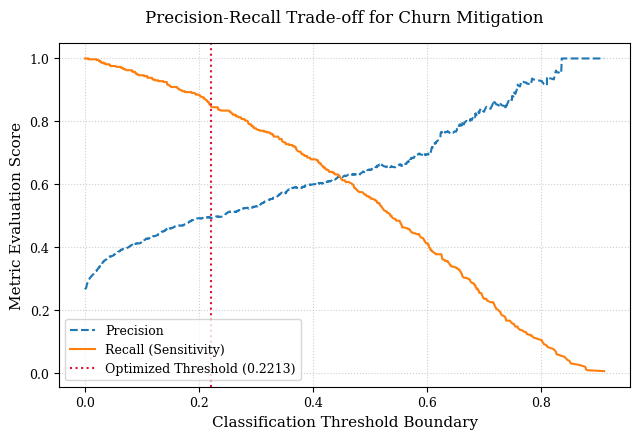

In [5]:
def plot_precision_recall_threshold(y_true, y_prob, target_recall=0.85, save_path=None):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    
    # Calculate optimal threshold dynamically based on target_recall
    optimal_idx = np.where(recalls >= target_recall)[0][-1]
    optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else thresholds[-1]
    
    plt.figure(figsize=(6.5, 4.5))
    plt.plot(thresholds, precisions[:-1], label='Precision', linestyle='--')
    plt.plot(thresholds, recalls[:-1], label='Recall (Sensitivity)', linestyle='-')
    
    plt.axvline(x=optimal_threshold, color='crimson', linestyle=':', 
                label=f'Optimized Threshold ({optimal_threshold:.4f})')
    
    plt.title('Precision-Recall Trade-off for Churn Mitigation', pad=15)
    plt.xlabel('Classification Threshold Boundary')
    plt.ylabel('Metric Evaluation Score')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower left')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"💾 PR-Curve Chart exported to: {save_path}")
    plt.show()

# Thực thi vẽ và lưu PR-Curve vào thư mục MODEL_DIR
plot_precision_recall_threshold(
    y_test, 
    y_pred_proba, 
    target_recall=0.85, 
    save_path=os.path.join(MODEL_DIR, "precision_recall_tradeoff.png")
)

💾 Learning Curve Chart exported to: d:\FPTU_Study\SU2026\ADY201m\Project_ADY201m_GR01_AI2009_H1\notebooks\artifacts\xgb_learning_curve.png


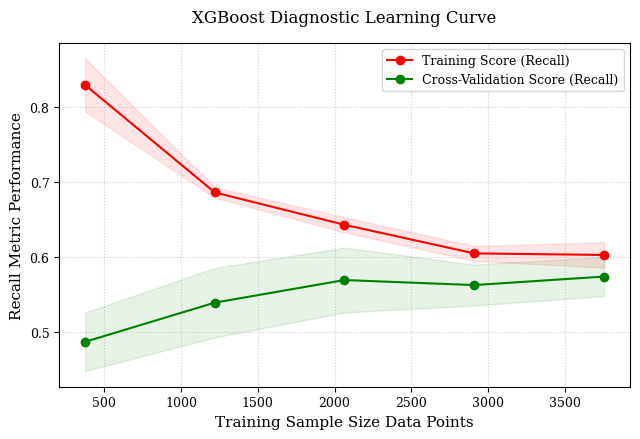

In [6]:
def plot_learning_curve(estimator, X, y, title="Learning Curves (XGBoost)", save_path=None):
    plt.figure(figsize=(6.5, 4.5))
    
    # Note: cv=3 is used for speed, scoring is 'recall' to match project objective
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='recall'
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Plot variance fills
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    # Plot means
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score (Recall)")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score (Recall)")
    
    plt.title(title, pad=15)
    plt.xlabel("Training Sample Size Data Points")
    plt.ylabel("Recall Metric Performance")
    plt.legend(loc="best")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"💾 Learning Curve Chart exported to: {save_path}")
    plt.show()

# Thực thi vẽ và lưu Learning Curve vào thư mục MODEL_DIR
plot_learning_curve(
    model, 
    X_train, 
    y_train, 
    "XGBoost Diagnostic Learning Curve", 
    save_path=os.path.join(MODEL_DIR, "xgb_learning_curve.png")
)